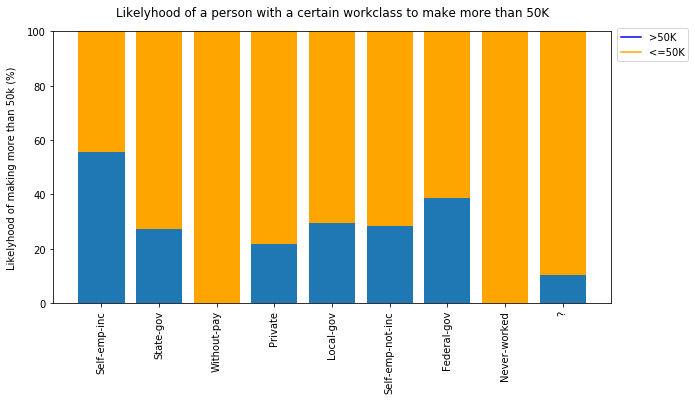

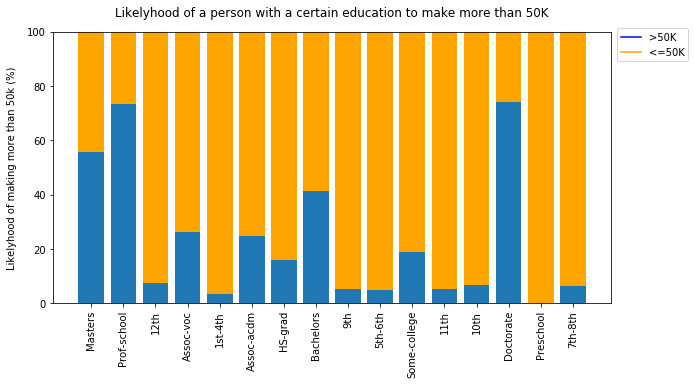

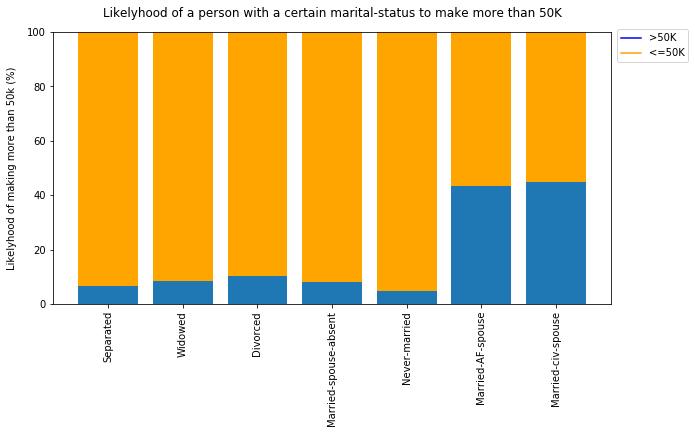

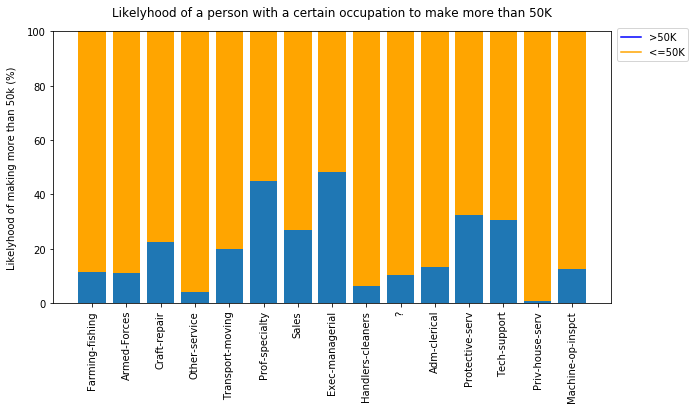

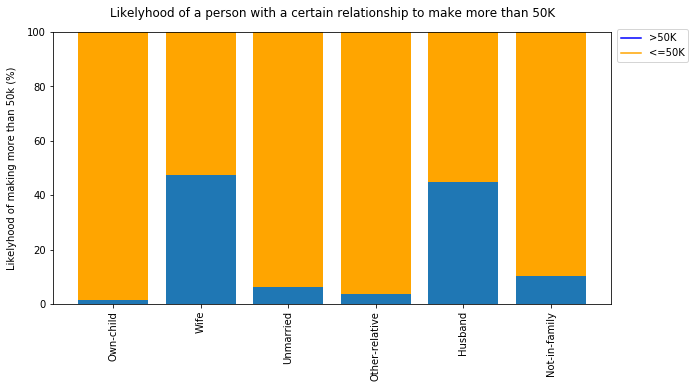

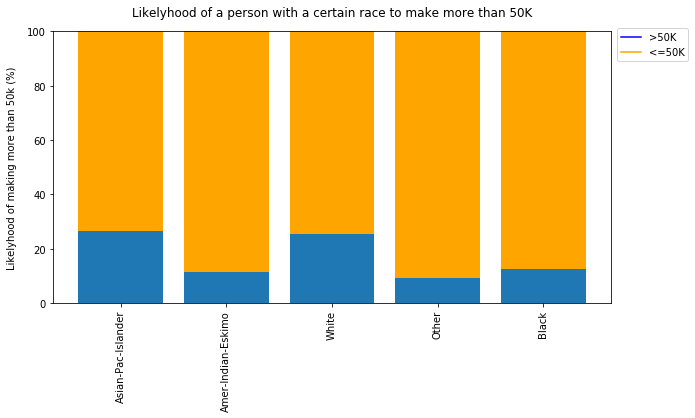

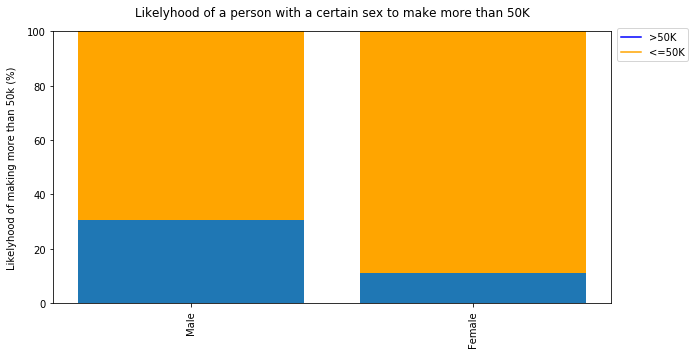

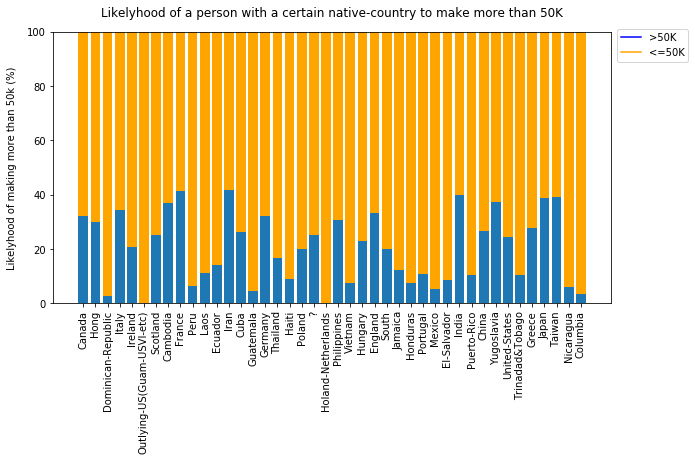

In [29]:
import matplotlib.pyplot as plt
import sqlite3 
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

df = pd.read_csv("adult.data.txt", header=None, delimiter=', ', engine='python', names=["age", "workclass", "fnlwgt", "education", "education-num", "marital-status", "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"]);

columns = ["workclass", "education", "marital-status", "occupation", "relationship", "race", "sex", "native-country"]

current = 0
for groupBy in columns:
    current = current + 1
    
    total = {}
    count = 0
    for val in df[groupBy].unique():
        total[val] = [0, 0, 0]
        count = count + 1

    for index, row in df.iterrows():
        record = total[row[groupBy]]

        if row["income"] == ">50K":
            record[0] = record[0] + 1
        if row["income"] == "<=50K":
            record[1] = record[1] + 1

        record[2] = record[2] + 1



    def format(pct):
        return "{:.1f}%".format(pct)

    plt.rcParams['figure.figsize'] = [10, 5]

    def calcPcnt(a, b):
        return a * 100.0 / b 

    dataPoints = []
    dataPointsTop = []
    labels = []
    for key in total:
        value = calcPcnt(total[key][0], total[key][2])
        dataPoints.append(value)
        dataPointsTop.append(100 - value)
        labels.append(key)
    
    plt.figure(current)
    plt.legend(custom_lines, [">50K", "<=50K"], loc=(1.01,0.89))
    
    plt.bar(range(count), dataPoints)
    plt.bar(range(count), dataPointsTop, bottom=dataPoints, color='orange')

    custom_lines = [Line2D([0], [0], color='blue'),
                Line2D([0], [0], color='orange')]

    x = np.arange(count)
    plt.xticks(x, labels, rotation = 90)
    plt.rc('axes', axisbelow=False)
    plt.ylim(0, 100)

    plt.ylabel('Likelyhood of making more than 50k (%)', labelpad=10)
    plt.title('Likelyhood of a person with a certain ' + groupBy + ' to make more than 50K', pad=15)
    plt.show()